In [4]:
from google.colab import drive
drive.mount('/content/drive')
# libs from description

import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab.patches import cv2_imshow

Mounted at /content/drive


A) Write a Python script to resize a color image of your choice to 75% of its original dimensions. Save the resized image as a PNG file.

In [5]:
# path to file
input_folder = '/content/drive/MyDrive/Colab Notebooks/CS423'
import os
test_image = None

# Try to load your actual image first
if os.path.exists(input_folder):
    files = os.listdir(input_folder)
    image_files = [f for f in files if f.lower().endswith(('.jpg', '.jpeg', '.png', '.bmp'))]
    #print('image_files',image_files)
    if image_files:
        image_path = os.path.join(input_folder, image_files[0]) # read the first image
        print(image_path)
        test_image = cv2.imread(image_path)
        if test_image is not None:
            print(f" Using your actual image: {image_files[0]}")
        else:
            test_image = None

if test_image is None:
    print("No images are found in the path")

/content/drive/MyDrive/Colab Notebooks/CS423/parrot.jpg
 Using your actual image: parrot.jpg


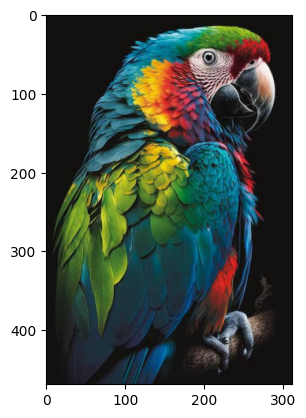

In [10]:
original= test_image.copy()
scale_factor = 0.75  # 75% of original size
new_width = int(original.shape[1] * scale_factor)
new_height = int(original.shape[0] * scale_factor)
resized = cv2.resize(original, (new_width, new_height), interpolation=cv2.INTER_AREA)
plt.imshow(cv2.cvtColor(resized, cv2.COLOR_BGR2RGB))

Image successfully saved as saved_image1.png


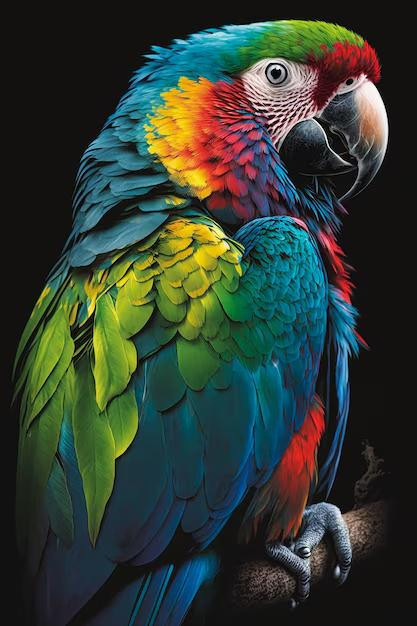

In [13]:
download_file = test_image.copy()

filename = "saved_image1.png"
cv2.imwrite(filename, download_file)

print(f"Image successfully saved as {filename}")
#checking if image downloaded successfully
check_image = cv2.imread("saved_image1.png")
cv2_imshow(check_image)

B) Convert the image to grayscale and apply a Gaussian blur with a sigma value of 2. Display the blurred
grayscale image.

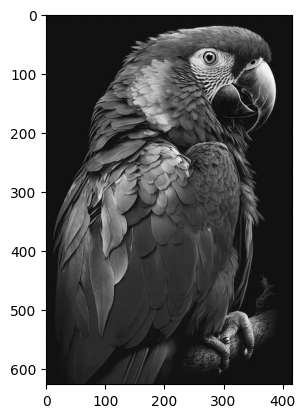

In [15]:
grayscale_img = test_image.copy()

grayscale = cv2.cvtColor(grayscale_img, cv2.COLOR_BGR2GRAY)

# cmap='gray' is needed otherwise, it looks different
plt.imshow(grayscale, cmap='gray')

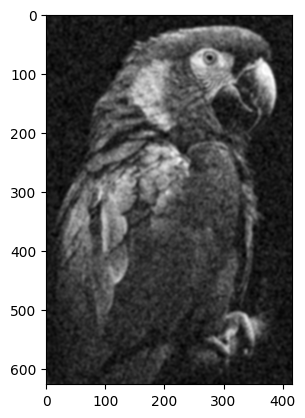

In [23]:
# gausian blur to the "grayscale"

#when showing gaussian_img cmap = gray needed
gaussian_img = grayscale.copy()

# moise added before blur
noisy_image = gaussian_img.copy()
noise_max = 100
noise = np.random.randint(-noise_max, noise_max, gaussian_img.shape, dtype=np.int16)
noisy_image = np.clip(noisy_image.astype(np.int16) + noise, 0, 255).astype(np.uint8)


geussian = cv2.GaussianBlur(noisy_image, (9,9), 2)
#plt.imshow(noisy_image, cmap = 'gray')
plt.imshow(geussian, cmap = 'gray')

C) Apply edge detec on using the Canny algorithm to the grayscale image. Display the edges found in the
image.

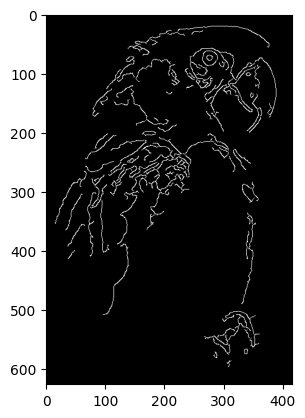

In [24]:
canny = geussian.copy()

edge = cv2.Canny(canny, 50, 150)

plt.imshow(edge, cmap = 'gray')

D) Create a binary mask from the edge-detected image (edges are white, and the rest is black). Apply this mask to the original color image, making the edges prominent while dimming the rest of the image. Display the result.

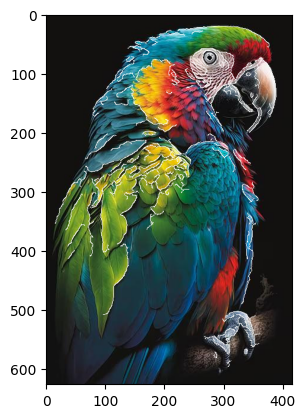

In [39]:

#masked1 = cv2.bitwise_and(org_img_rgb, org_img_rgb, mask=edged_image)
#dimmed = (org_img_rgb * 0.3).astype(np.uint8)
#masked3 = dimmed.copy()
#masked3[edged_image == 255] = org_img_rgb[edged_image == 255]

edged_image = edge.copy()
org_image = test_image.copy()

org_img_rgb = cv2.cvtColor(org_image, cv2.COLOR_BGR2RGB)
plt.imshow(org_img_rgb)


edge_rgb = cv2.cvtColor(edged_image, cv2.COLOR_GRAY2RGB)

edge_enhancement_factor = 2.0

blended = cv2.addWeighted(org_img_rgb, 1, edge_rgb, edge_enhancement_factor, 0)

plt.imshow(blended)



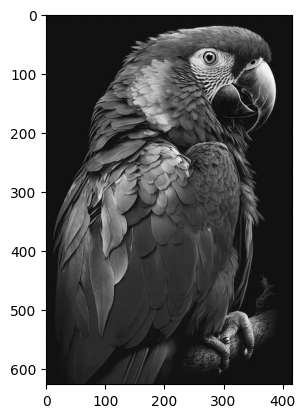

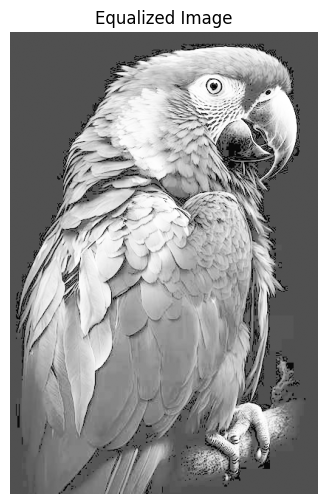

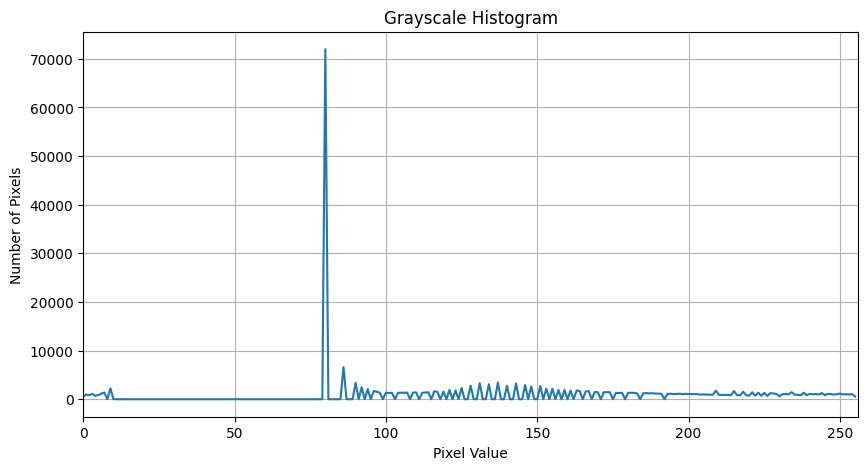

In [32]:
histogram = grayscale.copy()
plt.imshow(histogram, cmap ='gray')

equalized = cv2.equalizeHist(histogram)

hist = cv2.calcHist([equalized], [0], None, [256], [0, 256])

plt.figure(figsize=(6,6))
plt.title("Equalized Image")
plt.imshow(equalized, cmap='gray')
plt.axis('off')
plt.show()

# Plot the histogram
plt.figure(figsize=(10, 5))
plt.title("Grayscale Histogram")
plt.xlabel("Pixel Value")
plt.ylabel("Number of Pixels")
plt.plot(hist)
plt.xlim([0, 256])
plt.grid(True)
plt.show()
